# AprilTag 자세 추정 — 영상으로 확인

`Testing_apriltag.mp4` 를 한 프레임씩 넘기며 태그를 찾고, 자세(x, y, z, roll, pitch, yaw)가
어떻게 변하는지 본다.

**이 노트북은 알고리즘을 새로 짜지 않는다.** 전부 `src/` 와 `utils/` 에서 불러다 쓴다.

```
src/image_source.py   이미지 얻기        →  from_video, CameraIntrinsics
src/detection.py      태그 찾기          →  make_detector, detect
src/pose.py           자세 구하기        →  estimate_pose, draw_axes
utils/util.py         좌표 변환          →  invert_T, r2rpy ...
```

In [2]:
import sys, time
from pathlib import Path

# 프로젝트 루트(apriltag/)를 import 경로에 추가 — tools/ 에서 실행하므로 한 단계 위
ROOT = Path.cwd().parent if Path.cwd().name == "tools" else Path.cwd()
sys.path.insert(0, str(ROOT))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

from src import (CameraIntrinsics, to_gray,
                 make_detector, detect,
                 estimate_pose, pose_to_xyzrpy, camera_pose_in_tag,
                 draw_axes, draw_corners)

plt.rcParams["font.family"] = "Malgun Gothic"   # 그래프 한글
plt.rcParams["axes.unicode_minus"] = False

print("불러온 모듈 위치:", ROOT)

불러온 모듈 위치: /home/jeongmin/work/projects/krri/apriltag


## 1. 설정

**카메라 내부파라미터가 없다.** 이 영상을 찍은(렌더링한) 카메라의 fx, fy, cx, cy 를 모른다.
그래서 화각을 가정해서 계산한다.

$$ f_x = \frac{W/2}{\tan(\text{HFOV}/2)} $$

이 값이 틀리면 **거리(z)가 그 비율만큼 통째로 틀어진다.** 각도는 비교적 덜 민감하다.
실물 카메라를 사면 체스보드 캘리브레이션으로 진짜 값을 구해서 여기만 바꾸면 된다.

In [3]:
VIDEO    = Path("/home/jeongmin/work/projects/krri/data/apriltag/Testing_apriltag.mp4")
TAG_SIZE = 0.16          # [m] 태그 실제 한 변 (검은 테두리 포함). 모르면 가정값
HFOV_DEG = 60.0          # [deg] 수평 화각 가정

cap = cv2.VideoCapture(str(VIDEO))
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = cap.get(cv2.CAP_PROP_FPS)
N   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

fx = (W / 2) / np.tan(np.deg2rad(HFOV_DEG) / 2)
intr = CameraIntrinsics(fx=fx, fy=fx, cx=W/2, cy=H/2, width=W, height=H)

print(f"영상   : {W}x{H}  {FPS:.0f}fps  {N}프레임  {N/FPS:.1f}초")
print(f"가정값 : HFOV={HFOV_DEG}도 → fx=fy={fx:.1f}, cx={W/2:.1f}, cy={H/2:.1f}")
print(f"태그   : {TAG_SIZE} m")

영상   : 1920x1080  24fps  80프레임  3.3초
가정값 : HFOV=60.0도 → fx=fy=1662.8, cx=960.0, cy=540.0
태그   : 0.16 m


## 2. 프레임 전부 읽어서 자세 계산

먼저 한 번에 다 돌려놓고, 그 다음에 재생하면서 본다.

In [4]:
detector = make_detector()          # tag36h11

frames, records = [], []
cap = cv2.VideoCapture(str(VIDEO))
i = 0
while True:
    ok, bgr = cap.read()
    if not ok:
        break

    results = detect(detector, to_gray(bgr))       # ② 태그 찾기

    vis = bgr.copy()
    row = {"frame": i, "t": i / FPS, "n_tags": len(results)}
    for r in results:
        T_cam_tag, e0, e1 = estimate_pose(detector, r, intr, TAG_SIZE)   # ③ 자세
        v = pose_to_xyzrpy(T_cam_tag)
        draw_corners(vis, r)
        draw_axes(vis, intr.params, TAG_SIZE, T_cam_tag)
        row.update({"id": r.tag_id, **v, "err": e1,
                    "margin": r.decision_margin})
    frames.append(vis)
    records.append(row)
    i += 1
cap.release()

n_ok = sum(1 for r in records if r["n_tags"] > 0)
print(f"{len(records)} 프레임 중 {n_ok} 프레임에서 검출 ({100*n_ok/len(records):.0f}%)")

80 프레임 중 15 프레임에서 검출 (19%)


## 3-1. 영상에 새겨진 정답과 대조

이 영상은 합성 렌더링이라 좌측 상단에 **정답이 HUD 로 찍혀 있다.**

```
Center X coord: -10.0     태그 중심의 화면중앙 대비 가로 오프셋 [px]
Center Y coord: -19.0     세로 오프셋 [px]  (위쪽이 +)
Tag ID: 0
```

우리 검출 결과와 맞는지 본다. 영상 좌표는 **아래쪽이 +** 라서 Y 는 부호가 뒤집혀야 정상이다.

In [5]:
HUD = {0: (-10.0, -19.0)}      # 프레임: (Center X, Center Y) — 영상에서 눈으로 읽은 값

print(f"{'frame':>5} {'HUD':>16} {'우리 검출':>16} {'차이[px]':>10}")
for idx, (hx, hy) in HUD.items():
    r = records[idx]
    if not r["n_tags"]:
        continue
    cap = cv2.VideoCapture(str(VIDEO)); cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    _, bgr = cap.read(); cap.release()
    cx, cy = detect(detector, to_gray(bgr))[0].center
    ox, oy = cx - W/2, -(cy - H/2)          # 영상 Y 는 아래가 + 라 뒤집어 맞춘다
    print(f"{idx:>5} {f'({hx:+.1f},{hy:+.1f})':>16} {f'({ox:+.1f},{oy:+.1f})':>16} "
          f"{np.hypot(ox-hx, oy-hy):>10.2f}")
print("\n→ 픽셀 단위로 일치하면 검출 위치가 맞다는 뜻이다.")

frame              HUD            우리 검출     차이[px]
    0    (-10.0,-19.0)     (-9.0,-19.5)       1.11

→ 픽셀 단위로 일치하면 검출 위치가 맞다는 뜻이다.


## 3. 재생 — 값이 시시각각 변하는 것 보기

왼쪽은 축을 그린 영상, 오른쪽은 그 순간의 자세값이다.
**X=빨강, Y=초록, Z=파랑.** Z축이 태그면에서 수직으로 솟아 보이면 자세가 맞은 것이다.

KeyboardInterrupt: 

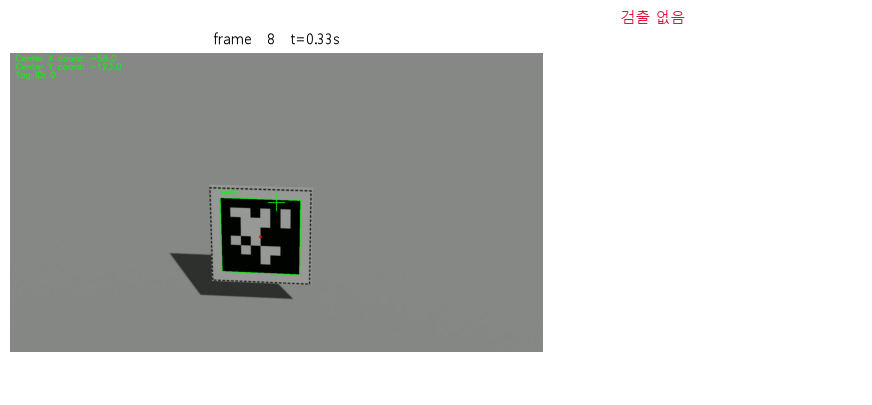

In [14]:
def play(frames, records, fps=8, size=(11, 5)):
    for f, r in zip(frames, records):
        fig, (ax0, ax1) = plt.subplots(1, 2, figsize=size,
                                       gridspec_kw={"width_ratios": [2.2, 1]})
        ax0.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)); ax0.axis("off")
        ax0.set_title(f"frame {r['frame']:>3}   t={r['t']:.2f}s", fontsize=11)

        ax1.axis("off")
        if r["n_tags"]:
            txt = (f"tag id : {r['id']}\n\n"
                   f"position [m]\n"
                   f"   x : {r['x']:+.4f}\n"
                   f"   y : {r['y']:+.4f}\n"
                   f"   z : {r['z']:+.4f}\n"
                   f"   거리 : {r['distance']:.4f}\n\n"
                   f"orientation [deg]\n"
                   f"   roll  : {r['roll']:+7.2f}\n"
                   f"   pitch : {r['pitch']:+7.2f}\n"
                   f"   yaw   : {r['yaw']:+7.2f}\n\n"
                   f"재투영오차 : {r['err']:.3f}")
            color = "black"
        else:
            txt, color = "검출 없음", "crimson"
        fam = "monospace" if r["n_tags"] else plt.rcParams["font.family"][0]
        ax1.text(0, 1, txt, va="top", ha="left", family=fam,
                 fontsize=11, color=color, transform=ax1.transAxes)

        clear_output(wait=True)
        display(fig)
        plt.close(fig) 
        time.sleep(5 / fps)

play(frames, records)

## 4. 전체 구간 그래프

재생으로는 흐름이 안 보이니 한 장에 모은다. 끊긴 구간이 검출 실패 구간이다.

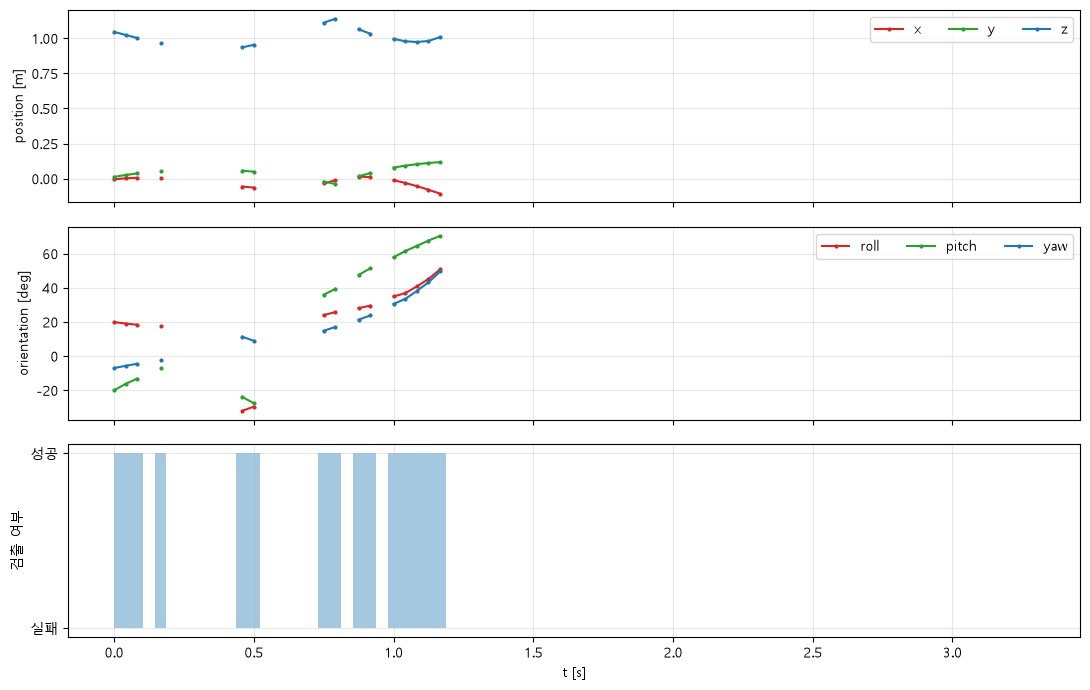

In [7]:
import matplotlib.pyplot as plt

t  = [r["t"] for r in records]
ok = [r["n_tags"] > 0 for r in records]
def series(k): return [r.get(k, np.nan) if r["n_tags"] else np.nan for r in records]

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for k, c in zip(["x", "y", "z"], ["tab:red", "tab:green", "tab:blue"]):
    axes[0].plot(t, series(k), ".-", color=c, label=k, ms=4)
axes[0].set_ylabel("position [m]"); axes[0].legend(ncol=3); axes[0].grid(alpha=.3)

for k, c in zip(["roll", "pitch", "yaw"], ["tab:red", "tab:green", "tab:blue"]):
    axes[1].plot(t, series(k), ".-", color=c, label=k, ms=4)
axes[1].set_ylabel("orientation [deg]"); axes[1].legend(ncol=3); axes[1].grid(alpha=.3)

axes[2].fill_between(t, 0, [1 if o else 0 for o in ok], step="mid", alpha=.4)
axes[2].set_ylabel("검출 여부"); axes[2].set_xlabel("t [s]")
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["실패", "성공"]); axes[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. 태그 기준으로 뒤집기

`estimate_pose` 가 주는 것은 **카메라 기준 태그**다. 도킹에서는 반대가 필요하다 —
탑재부(태그) 기준으로 내가 어디 있는지. `camera_pose_in_tag` 로 뒤집는다.

In [8]:
for r, f in zip(records, frames):
    if r["n_tags"]:
        cap = cv2.VideoCapture(str(VIDEO)); cap.set(cv2.CAP_PROP_POS_FRAMES, r["frame"])
        _, bgr = cap.read(); cap.release()
        d = detect(detector, to_gray(bgr))[0]
        T_cam_tag, _, _ = estimate_pose(detector, d, intr, TAG_SIZE)
        T_tag_cam = camera_pose_in_tag(T_cam_tag)
        a, b = pose_to_xyzrpy(T_cam_tag), pose_to_xyzrpy(T_tag_cam)
        print(f"frame {r['frame']}")
        print(f"  카메라 기준 태그 : xyz=({a['x']:+.3f},{a['y']:+.3f},{a['z']:+.3f})  "
              f"yaw={a['yaw']:+.1f}도  거리={a['distance']:.3f}m")
        print(f"  태그 기준 카메라 : xyz=({b['x']:+.3f},{b['y']:+.3f},{b['z']:+.3f})  "
              f"yaw={b['yaw']:+.1f}도  거리={b['distance']:.3f}m")
        print("  → 거리는 같고 방향만 뒤집힌다")
        break

frame 0
  카메라 기준 태그 : xyz=(-0.005,+0.013,+1.046)  yaw=-7.0도  거리=1.046m
  태그 기준 카메라 : xyz=(-0.352,-0.347,-0.922)  yaw=-0.1도  거리=1.046m
  → 거리는 같고 방향만 뒤집힌다


## 6. 정리

- 자세 추정 자체는 **검출만 되면 잘 나온다.**
- 뒤쪽 프레임에서 끊기는 것은 알고리즘 문제가 아니라 **태그가 멀어져 작아지고 대비가 낮아져서**다.
  실차에서도 같은 일이 생기므로, 태그를 크게 만들거나 여러 개 붙여야 하는 이유가 된다.
- **거리(z) 값은 아직 믿으면 안 된다.** `HFOV_DEG` 와 `TAG_SIZE` 를 가정해서 넣었기 때문이다.
  둘 중 하나라도 틀리면 거리가 그 비율로 통째로 어긋난다.

### 실물 카메라를 사면 바꿀 곳
| 위치 | 지금 | 실물 |
|---|---|---|
| `intr` | 화각 가정으로 계산 | 체스보드 캘리브레이션 값 |
| `TAG_SIZE` | 가정값 | 인쇄한 태그 실측 |
| 영상 입력 | `cv2.VideoCapture(파일)` | `src.image_source.from_camera()` |